# Grammar scoring for spoken English

SHL Hiring Assessment 2026. Each clip is a 6–61 s spoken answer with a grammar score from 1 to 5 (MOS-style rubric, averaged ratings). The metric is RMSE, and Pearson correlation is also reported.

**Approach in one paragraph.** Audio is transcribed with an open ASR model that keeps disfluencies (Parakeet-TDT 0.6B). Each clip is then described in three ways: (1) pooled hidden states from two speech encoders (Whisper-small.en and Parakeet's FastConformer), (2) interpretable features from the transcript and its word timings (pauses, speech rate, ASR confidence, repetitions, lexical diversity, syntax), and (3) a grammatical-acceptability model (RoBERTa fine-tuned on CoLA) applied sentence by sentence. Each block gets its own regressor, cross-validated on a shared set of folds, and a small ridge stack combines them with an explicit correction for the 45-second recording batch that dominates the test set.

The sections below follow the order the work was done in: data checks, feature extraction, per-block models, stacking, and error analysis. Numbers quoted in the text come from the outputs of this run.

## 0. Setup

Everything runs on CPU. Pretrained weights come from GitHub releases (sherpa-onnx ONNX exports and spaCy model wheels), so the notebook needs internet access the first time. Expensive steps write to `cache/` and are skipped when their output already exists.

In [1]:
import os, sys, json, glob, re, math, time, random, subprocess, warnings
warnings.filterwarnings('ignore')

def ensure(pkg, pip_name=None):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pip_name or pkg], check=True)

for pkg, pip_name in [('sherpa_onnx', 'sherpa-onnx'), ('onnx', None), ('onnxruntime', None), ('soundfile', None),
                      ('librosa', None), ('wordfreq', None), ('lightgbm', None), ('spacy', None)]:
    ensure(pkg, pip_name)

SPACY_WHEELS = 'https://github.com/explosion/spacy-models/releases/download'
for m in ['en_core_web_sm', 'en_core_web_trf']:
    ensure(m, f'{SPACY_WHEELS}/{m}-3.8.0/{m}-3.8.0-py3-none-any.whl')

import numpy as np, pandas as pd, soundfile as sf
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def find_data():
    for root in ['/kaggle/input', './data']:
        for hit in glob.glob(f'{root}/**/train.csv', recursive=True):
            d = os.path.dirname(hit)
            if os.path.isdir(f'{d}/train') and os.path.isdir(f'{d}/test'):
                return d
    raise FileNotFoundError('competition data not found')

DATA = find_data()
WORK = '/kaggle/working' if os.path.isdir('/kaggle/working') else '.'
CACHE, MODELS = f'{WORK}/cache', f'{WORK}/models'
os.makedirs(CACHE, exist_ok=True); os.makedirs(MODELS, exist_ok=True)
N_THREADS = os.cpu_count() or 2
SEED = 42
print('data:', DATA, '| work:', WORK, '| threads:', N_THREADS)

data: ./data/Dataset_Final | work: . | threads: 2


In [2]:
SHERPA = 'https://github.com/k2-fsa/sherpa-onnx/releases/download/asr-models'
PARAKEET_DIR = f'{MODELS}/sherpa-onnx-nemo-parakeet-tdt-0.6b-v2-int8'
WHISPER_DIR = f'{MODELS}/sherpa-onnx-whisper-small.en'

def fetch(name):
    if not os.path.isdir(f'{MODELS}/{name}'):
        subprocess.run(f'curl -sSL {SHERPA}/{name}.tar.bz2 | tar xj -C {MODELS}', shell=True, check=True)

fetch('sherpa-onnx-nemo-parakeet-tdt-0.6b-v2-int8')
fetch('sherpa-onnx-whisper-small.en')
print(sorted(os.listdir(MODELS)))

['cola_roberta.pt', 'dl.log', 'en_core_web_lg-3.8.0-py3-none-any.whl', 'en_core_web_sm-3.8.0-py3-none-any.whl', 'en_core_web_trf-3.8.0-py3-none-any.whl', 'parakeet_layers.int8.onnx', 'parakeet_layers.int8.onnx.data', 'sherpa-onnx-nemo-parakeet-tdt-0.6b-v2-int8', 'sherpa-onnx-whisper-small.en', 'whisper_small_en_layers.onnx', 'whisper_small_en_layers.onnx.data']


## 1. Data checks

Things worth knowing before modelling:
* `sample_submission.csv` is stale: it lists 204 ids and only 25 of them are in `test.csv`. The submission follows `test.csv` (216 rows).
* The `train/` and `test/` folders reuse file names for different recordings (212 names appear in both), so paths are always resolved per split.
* 37 training clips are labelled 0.0. A 0 is not on the 1–5 rubric, and these clips form one contiguous block of ids (5037–5073), so they look like a separate batch. They are left out of training and evaluation.

In [3]:
tr_all = pd.read_csv(f'{DATA}/train.csv'); te = pd.read_csv(f'{DATA}/test.csv'); ss = pd.read_csv(f'{DATA}/sample_submission.csv')
for df, split in [(tr_all, 'train'), (te, 'test')]:
    df['dur'] = [sf.info(f'{DATA}/{split}/{f}').duration for f in df.filename]
    df['id'] = df.filename.str.extract(r'(\d+)')[0].astype(int)
print('train', tr_all.shape, 'test', te.shape, 'sample_submission', ss.shape)
print('sample_submission ids found in test.csv:', ss.filename.isin(te.filename).sum())
print('file names shared by train and test folders:', len(set(tr_all.filename) & set(te.filename)))
zero = tr_all[tr_all.label == 0]
print(f'0.0 labels: {len(zero)} clips, ids {zero.id.min()}-{zero.id.max()}')
tr = tr_all[tr_all.label > 0].reset_index(drop=True)
y = tr.label.values
print('training clips used:', len(tr), '| label mean %.3f sd %.3f' % (y.mean(), y.std()))

train (769, 4) test (216, 4) sample_submission (204, 2)
sample_submission ids found in test.csv: 25
file names shared by train and test folders: 212
0.0 labels: 37 clips, ids 5037-5073
training clips used: 732 | label mean 3.481 sd 1.014


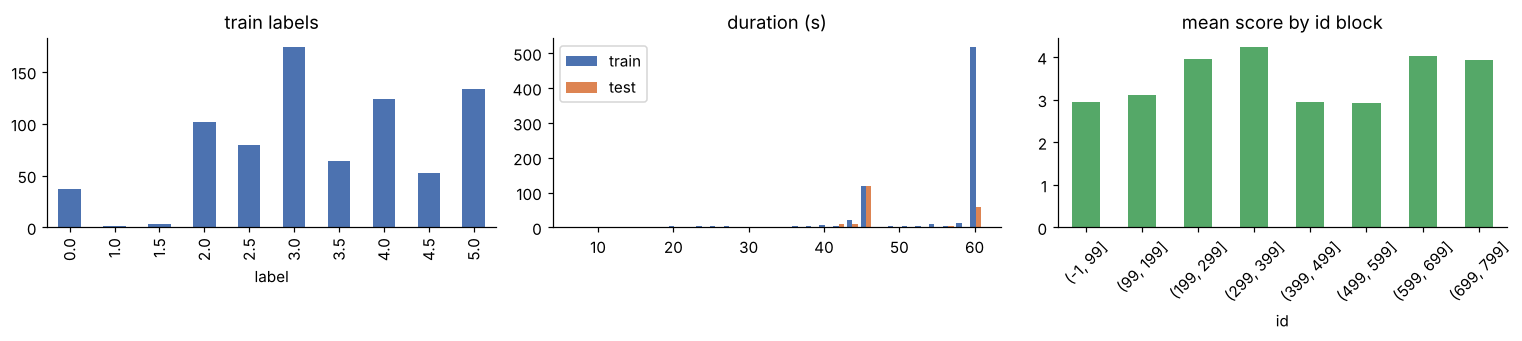

id     (-1, 99]  (99, 199]  (199, 299]  (299, 399]  (399, 499]  (499, 599]  (599, 699]  (699, 799]
score      2.94       3.10        3.95        4.24        2.93        2.92        4.01        3.93
short      0.94       0.43        0.15        0.06        0.09        0.02        0.09        0.06


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
tr_all.label.value_counts().sort_index().plot.bar(ax=ax[0], color='#4C72B0'); ax[0].set_title('train labels')
ax[1].hist([tr.dur, te.dur], bins=30, label=['train', 'test'], color=['#4C72B0', '#DD8452']); ax[1].legend(); ax[1].set_title('duration (s)')
b = tr.groupby(pd.cut(tr.id, [-1, 99, 199, 299, 399, 499, 599, 699, 799])).agg(score=('label', 'mean'), short=('dur', lambda d: (d < 50).mean()))
b.score.plot.bar(ax=ax[2], color='#55A868'); ax[2].set_title('mean score by id block'); ax[2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(b.round(2).T)

The training set is not one population. Ids 0–99 are almost all ~45 s clips (ids 100–199 about 40 %), and both blocks average around 3.0. Later id blocks are 60 s clips whose mean swings between 2.9 and 4.2 from block to block. The test set is 63 % 45-second clips, so it looks like the first blocks.

An adversarial check (section 4) confirms this: a classifier trying to separate test from train clips gives its highest "test-like" scores to train ids 0–199. Two consequences shape the rest of the notebook:
* every model is also scored on the **test-like subset** (train ids < 200), not just on all clips;
* the stack gets an explicit indicator for the 45-second batch, because models trained mostly on 60 s clips over-predict those clips by 0.12–0.18 (measured in section 8).

## 2. Transcription

Parakeet-TDT-0.6B-v2 (int8 ONNX via sherpa-onnx). It was chosen over Whisper for this step because Whisper tends to tidy up what it hears: it drops repetitions and quietly repairs agreement errors, which is exactly the signal a grammar score depends on. Parakeet keeps fillers, restarts and repeated words, and it returns per-token timestamps and log-probabilities, which feed the pause and confidence features later. It runs at roughly 0.1× real time on two CPU threads.

In [5]:
import sherpa_onnx

def jobs():
    return [(s, f) for s in ['test', 'train'] for f in pd.read_csv(f'{DATA}/{s}.csv').filename]

def transcribe_all(threads=N_THREADS):
    out_dir = f'{CACHE}/asr_parakeet'; os.makedirs(out_dir, exist_ok=True)
    todo = [(s, f) for s, f in jobs() if not os.path.exists(f'{out_dir}/{s}__{f[:-4]}.json')]
    if not todo:
        return
    rec = sherpa_onnx.OfflineRecognizer.from_transducer(
        encoder=f'{PARAKEET_DIR}/encoder.int8.onnx', decoder=f'{PARAKEET_DIR}/decoder.int8.onnx',
        joiner=f'{PARAKEET_DIR}/joiner.int8.onnx', tokens=f'{PARAKEET_DIR}/tokens.txt',
        num_threads=threads, model_type='nemo_transducer', decoding_method='greedy_search')
    for split, f in todo:
        x, sr = sf.read(f'{DATA}/{split}/{f}', dtype='float32')
        s = rec.create_stream(); s.accept_waveform(sr, x); rec.decode_stream(s); r = s.result
        out = dict(text=r.text, tokens=list(r.tokens), timestamps=[float(v) for v in r.timestamps],
                   durations=[float(v) for v in r.durations], logp=[float(v) for v in r.ys_log_probs], audio_sec=len(x) / sr)
        json.dump(out, open(f'{out_dir}/{split}__{f[:-4]}.json', 'w'))

t0 = time.time(); transcribe_all(); print(f'transcription step: {time.time() - t0:.0f}s')

def load_asr(split, f):
    return json.load(open(f'{CACHE}/asr_parakeet/{split}__{f[:-4]}.json'))

for f in tr.sort_values('label').filename.iloc[[5, 400, 725]]:
    print(f"[{tr.set_index('filename').label[f]}] {load_asr('train', f)['text'][:260]}...\n")

transcription step: 0s


## 3. Speech-encoder embeddings

Raters hear the speaker, not a transcript, and much of what separates a 2 from a 4 (hesitation, rhythm, confident phrasing) is audible directly. Pooled encoder states carry that signal well. Two encoders are used:

* **Whisper-small.en encoder** (12 layers, d=768). The sherpa-onnx export only returns cross-attention keys/values, so the graph is edited to also output the residual stream after every block. Each clip is covered by full 30 s windows (the last one right-aligned) so the encoder never sees long zero-padded stretches; per layer, mean and std over frames are kept.
* **Parakeet FastConformer encoder** (24 layers, d=1024, 80 ms frames), same idea. Its input features are re-implemented from NeMo's preprocessing (128 log-mels, per-feature normalisation). To check them, a small greedy TDT decoder runs on top, and its transcripts are compared with sherpa-onnx's: a sensible front-end should reproduce them closely.

In [6]:
import onnx, onnxruntime as ort

def _hz_to_mel(f):
    f = np.asanyarray(f, dtype=np.float64)
    return np.where(f >= 1000.0, 15.0 + np.log(np.maximum(f, 1e-10) / 1000.0) / (np.log(6.4) / 27.0), f / (200.0 / 3))

def _mel_to_hz(m):
    m = np.asanyarray(m, dtype=np.float64)
    return np.where(m >= 15.0, 1000.0 * np.exp((np.log(6.4) / 27.0) * (m - 15.0)), m * (200.0 / 3))

def slaney_mel(sr=16000, n_fft=400, n_mels=80):
    """Same filters as librosa.filters.mel(norm='slaney')."""
    fftfreqs = np.fft.rfftfreq(n_fft, 1.0 / sr)
    mel_f = _mel_to_hz(np.linspace(_hz_to_mel(0.0), _hz_to_mel(sr / 2), n_mels + 2))
    fdiff = np.diff(mel_f); ramps = mel_f[:, None] - fftfreqs[None, :]
    w = np.maximum(0, np.minimum(-ramps[:-2] / fdiff[:-1, None], ramps[2:] / fdiff[1:, None]))
    return (w * (2.0 / (mel_f[2:] - mel_f[:-2]))[:, None]).astype(np.float32)

# ---- Whisper log-mel (matches openai/whisper.audio.log_mel_spectrogram)
W_MEL = slaney_mel(16000, 400, 80)
W_WIN = (0.5 - 0.5 * np.cos(2 * np.pi * np.arange(400) / 400)).astype(np.float32)

def whisper_log_mel(audio):
    x = np.pad(audio.astype(np.float32), (200, 200), mode='reflect')
    n = 1 + (len(x) - 400) // 160
    frames = np.lib.stride_tricks.as_strided(x, (n, 400), (x.strides[0] * 160, x.strides[0]))
    spec = np.abs(np.fft.rfft(frames * W_WIN, axis=1)) ** 2
    logm = np.log10(np.maximum(W_MEL @ spec[:-1].T, 1e-10))
    logm = np.maximum(logm, logm.max() - 8.0)
    return ((logm + 4.0) / 4.0).astype(np.float32)

def whisper_windows(x, win=30 * 16000):
    n = len(x)
    if n <= win:
        return [(np.pad(x, (0, win - n)), int(np.ceil(n / 320)))]
    starts = list(range(0, n - win + 1, win))
    if starts[-1] + win < n:
        starts.append(n - win)
    return [(x[s:s + win], 1500) for s in starts]

def expose_whisper_layers(src, dst):
    m = onnx.load(src)
    n_layer = int({p.key: p.value for p in m.metadata_props}['n_audio_layer'])
    want = [f'/audioEncoder/blocks.{i}/Add_1_output_0' for i in range(n_layer)]
    want.append([n.output[0] for n in m.graph.node if n.name.startswith('/audioEncoder/ln_post/') and n.op_type == 'Add'][-1])
    del m.graph.output[:]
    for w in want:
        m.graph.output.append(onnx.helper.make_tensor_value_info(w, onnx.TensorProto.FLOAT, None))
    onnx.save(m, dst, save_as_external_data=True, location=os.path.basename(dst) + '.data')

def session(path, threads=N_THREADS):
    so = ort.SessionOptions(); so.intra_op_num_threads = threads; so.inter_op_num_threads = 1
    return ort.InferenceSession(path, so, providers=['CPUExecutionProvider'])

def whisper_embed_all():
    out_dir = f'{CACHE}/whisper_small'; os.makedirs(out_dir, exist_ok=True)
    todo = [(s, f) for s, f in jobs() if not os.path.exists(f'{out_dir}/{s}__{f[:-4]}.npz')]
    if not todo:
        return
    path = f'{MODELS}/whisper_small_en_layers.onnx'
    if not os.path.exists(path):
        expose_whisper_layers(f'{WHISPER_DIR}/small.en-encoder.onnx', path)
    sess = session(path)
    for split, f in todo:
        x, _ = sf.read(f'{DATA}/{split}/{f}', dtype='float32')
        s1 = s2 = 0; cnt = 0
        for w, valid in whisper_windows(x):
            hs = sess.run(None, {'mel': whisper_log_mel(w)[None, :, :3000]})
            h = np.stack([a[0, :valid] for a in hs]).astype(np.float64)        # (13, T, 768)
            s1 = s1 + h.sum(1); s2 = s2 + (h ** 2).sum(1); cnt += valid
        mean = s1 / cnt; std = np.sqrt(np.maximum(s2 / cnt - mean ** 2, 0))
        np.savez(f'{out_dir}/{split}__{f[:-4]}.npz', mean=mean.astype(np.float32), std=std.astype(np.float32))

t0 = time.time(); whisper_embed_all(); print(f'whisper step: {time.time() - t0:.0f}s')

whisper step: 0s


In [7]:
# ---- Parakeet: NeMo-style features, layer outputs, and a greedy TDT decoder used as a check
P_MEL = slaney_mel(16000, 512, 128)
P_WIN = np.zeros(512, np.float32); P_WIN[56:456] = np.hanning(400)   # symmetric Hann centred in n_fft

def nemo_features(x):
    x = np.concatenate([x[:1], x[1:] - 0.97 * x[:-1]]).astype(np.float32)
    n_valid = len(x) // 160 + 1
    xp = np.pad(x, (256, 256)); n = 1 + (len(xp) - 512) // 160
    fr = np.lib.stride_tricks.as_strided(xp, (n, 512), (xp.strides[0] * 160, xp.strides[0]))
    feat = np.log(P_MEL @ (np.abs(np.fft.rfft(fr * P_WIN, axis=1)) ** 2).T + 2 ** -24)[:, :n_valid]
    mu = feat.mean(1, keepdims=True); sd = feat.std(1, ddof=1, keepdims=True) + 1e-5
    return ((feat - mu) / sd).astype(np.float32)

def expose_parakeet_layers(src, dst, n_layers=24):
    m = onnx.load(src)
    outs = list(m.graph.output) + [onnx.helper.make_tensor_value_info(
        f'/layers.{i}/norm_out/LayerNormalization_output_0', onnx.TensorProto.FLOAT, None) for i in range(n_layers)]
    del m.graph.output[:]; m.graph.output.extend(outs)
    onnx.save(m, dst, save_as_external_data=True, location=os.path.basename(dst) + '.data')

class Parakeet:
    def __init__(self, threads=N_THREADS):
        path = f'{MODELS}/parakeet_layers.int8.onnx'
        if not os.path.exists(path):
            expose_parakeet_layers(f'{PARAKEET_DIR}/encoder.int8.onnx', path)
        self.enc = session(path, threads)
        self.dec = session(f'{PARAKEET_DIR}/decoder.int8.onnx', 1)
        self.joi = session(f'{PARAKEET_DIR}/joiner.int8.onnx', 1)
        self.tokens = [l.rsplit(' ', 1)[0] for l in open(f'{PARAKEET_DIR}/tokens.txt', encoding='utf-8').read().splitlines()]
        self.blank = len(self.tokens) - 1

    def encode(self, x):
        f = nemo_features(x)
        o = self.enc.run(None, {'audio_signal': f[None], 'length': np.array([f.shape[1]], np.int64)})
        return o[0][0], int(o[1][0]), [h[0] for h in o[2:]]

    def _dec(self, tok, st):
        o = self.dec.run(None, {'targets': np.array([[tok]], np.int32), 'target_length': np.array([1], np.int32),
                                'states.1': st[0], 'onnx::Slice_3': st[1]})
        return o[0], (o[2], o[3])

    def greedy(self, enc, T, max_sym=10):
        st = (np.zeros((2, 1, 640), np.float32), np.zeros((2, 1, 640), np.float32))
        d, st_new = self._dec(self.blank, st); hyp, t, emitted = [], 0, 0
        while t < T:
            lo = self.joi.run(None, {'encoder_outputs': enc[None, :, t:t + 1], 'decoder_outputs': d})[0].reshape(-1)
            k = int(lo[:self.blank + 1].argmax()); dur = int(lo[self.blank + 1:].argmax())
            if k != self.blank:
                hyp.append(k); st = st_new; d, st_new = self._dec(k, st); emitted += 1
            if dur == 0 and (k == self.blank or emitted >= max_sym):
                dur = 1
            if dur > 0:
                emitted = 0
            t += dur
        return ''.join(self.tokens[i] for i in hyp).replace('▁', ' ').strip()

def parakeet_embed_all(pk):
    out_dir = f'{CACHE}/parakeet'; os.makedirs(out_dir, exist_ok=True)
    for split, f in jobs():
        out = f'{out_dir}/{split}__{f[:-4]}.npz'
        if os.path.exists(out):
            continue
        x, _ = sf.read(f'{DATA}/{split}/{f}', dtype='float32')
        _, T, layers = pk.encode(x)
        h = np.stack([l[:T] for l in layers])
        np.savez(out, mean=h.mean(1), std=h.std(1))

def wer(ref, hyp):
    r, h = ref.lower().split(), hyp.lower().split()
    d = np.arange(len(h) + 1)
    for i in range(1, len(r) + 1):
        prev, d[0] = d.copy(), i
        for j in range(1, len(h) + 1):
            d[j] = min(prev[j] + 1, d[j - 1] + 1, prev[j - 1] + (r[i - 1] != h[j - 1]))
    return d[len(h)] / max(len(r), 1)

pk = Parakeet()
check = []
for f in tr.filename.iloc[:12]:
    x, _ = sf.read(f'{DATA}/train/{f}', dtype='float32'); enc, T, _ = pk.encode(x)
    hyp = pk.greedy(enc, T); check.append((f, wer(load_asr('train', f)['text'], hyp), hyp))
check = pd.DataFrame(check, columns=['file', 'wer', 'own_decode'])
print('WER of own front-end + greedy TDT vs sherpa-onnx, 12 clips:', check.wer.round(3).tolist(), '| median', round(check.wer.median(), 3))
worst = check.sort_values('wer').iloc[-1]
print(f"\nlargest disagreement ({worst.file}):\n  sherpa-onnx: {load_asr('train', worst.file)['text'][:230]}\n  own:         {worst.own_decode[:230]}")
t0 = time.time(); parakeet_embed_all(pk); print(f'parakeet step: {time.time() - t0:.0f}s')

WER of own front-end + greedy TDT vs sherpa-onnx, 12 clips: [0.286, 0.031, 0.014, 0.124, 0.0, 0.194, 0.361, 0.0, 0.026, 0.009, 0.027, 0.025] | median 0.027
parakeet step: 0s


The two front-ends agree on most clips (median WER ≈ 3 %). They diverge only on a few hard clips, where the model is uncertain either way (on the most divergent clip, neither transcript is clearly right; the excerpts are left out of this copy because they come from competition audio). That is what two slightly different but correct front-ends look like on difficult audio, not a systematic bug, so the encoder states used below come from inputs the model handles properly.

## 4. Transcript, timing and prosody features

76 interpretable features per clip, in five groups:
* **timing**: speech rate, articulation rate, pause counts and durations, mean length of run between pauses (all from Parakeet token timestamps);
* **ASR confidence**: mean and low-percentile token log-probabilities. Ungrammatical or heavily accented speech is harder to decode, so low confidence is informative, not just noise;
* **disfluency**: fillers, immediate word and bigram repetitions, restarts;
* **lexical**: MTLD, type-token ratio on 50-word windows, word frequency (wordfreq Zipf), word length;
* **syntax** (spaCy): sentence length, parse depth, dependency distance, subordinate clauses, tense mix, POS ratios, plus a few conservative rule-based error counts (agreement, determiner–noun number, verb form after modals/auxiliaries/"to").

Prosody (energy dynamics, pitch range from YIN) comes from the waveform.

In [8]:
import librosa, spacy
from wordfreq import zipf_frequency

FILLERS = {'um', 'uh', 'erm', 'er', 'ah', 'hmm', 'mm', 'uhm', 'eh'}

def words_with_times(rec):
    """Merge BPE tokens into words; a word starts at a token with a leading space."""
    words = []
    for tok, ts, du, lp in zip(rec['tokens'], rec['timestamps'], rec['durations'], rec['logp']):
        if tok.startswith(' ') or not words:
            words.append([tok.strip(), ts, ts + du, [lp]])
        else:
            w = words[-1]; w[0] += tok; w[2] = ts + du; w[3].append(lp)
    out = []
    for w, s, e, lps in words:
        core = re.sub(r"[^\w']", '', w.lower())
        if core:
            out.append(dict(w=core, raw=w, s=s, e=e, lp=float(np.sum(lps)), lpmin=float(np.min(lps))))
    return out

def mtld(tokens, thr=0.72):
    def one_dir(seq):
        factors, types, n = 0.0, set(), 0
        for t in seq:
            n += 1; types.add(t)
            if len(types) / n <= thr:
                factors += 1; types, n = set(), 0
        if n:
            factors += (1 - len(types) / n) / (1 - thr)
        return len(seq) / factors if factors else len(seq)
    if len(tokens) < 10:
        return np.nan
    return (one_dir(tokens) + one_dir(tokens[::-1])) / 2

def timing_asr_disfl(rec):
    W = words_with_times(rec)
    dur = rec['audio_sec']; f = {'dur': dur}
    n = len(W); f['n_words'] = n
    if n < 2:
        return f
    toks = [w['w'] for w in W]
    gaps = np.array([W[i + 1]['s'] - W[i]['e'] for i in range(n - 1)])
    gaps = np.maximum(gaps, 0)
    span = W[-1]['e'] - W[0]['s']
    f['lead_sil'] = W[0]['s']; f['trail_sil'] = max(dur - W[-1]['e'], 0)
    f['speech_frac'] = span / dur
    f['wpm'] = 60 * n / dur
    f['wpm_span'] = 60 * n / max(span, 1e-3)
    phon = span - gaps[gaps > 0.25].sum()
    f['artic_rate'] = 60 * n / max(phon, 1e-3)
    for thr in (0.25, 0.5, 1.0):
        f[f'pause_{thr}_pm'] = 60 * (gaps > thr).sum() / max(span, 1e-3)
    f['pause_mean'] = gaps[gaps > 0.25].mean() if (gaps > 0.25).any() else 0.0
    f['pause_time_frac'] = gaps[gaps > 0.25].sum() / max(span, 1e-3)
    f['pause_max'] = gaps.max()
    # mean length of run (words between pauses > 0.25 s)
    runs = np.diff(np.r_[-1, np.where(gaps > 0.25)[0], n - 1])
    f['mlr'] = runs.mean(); f['mlr_max'] = runs.max()
    # ASR confidence
    lp = np.array([w['lp'] for w in W]); lpm = np.array([w['lpmin'] for w in W])
    f['lp_mean'] = lp.mean(); f['lp_p10'] = np.percentile(lp, 10)
    f['lowconf_frac'] = (lpm < -1.0).mean(); f['vlowconf_frac'] = (lpm < -3.0).mean()
    # disfluency
    f['filler_rate'] = sum(t in FILLERS for t in toks) / n
    rep1 = sum(toks[i] == toks[i + 1] for i in range(n - 1))
    rep2 = sum(toks[i:i + 2] == toks[i + 2:i + 4] for i in range(n - 3))
    f['rep1_rate'] = rep1 / n; f['rep2_rate'] = rep2 / n
    # restart: same word reappears within a 3-word window after a comma-free break (e.g. "went on a tour, went on")
    f['restart_rate'] = sum(toks[i] in toks[max(0, i - 4):i - 1] and toks[i] not in {'the', 'a', 'and', 'i', 'to'}
                            for i in range(2, n)) / n
    return f

def lexical(rec):
    toks = [w['w'] for w in words_with_times(rec) if w['w'] not in FILLERS]
    f = {}
    if len(toks) < 5:
        return f
    f['ttr50'] = np.mean([len(set(toks[i:i + 50])) / len(toks[i:i + 50]) for i in range(0, max(len(toks) - 49, 1), 25)])
    f['mtld'] = mtld(toks)
    z = np.array([zipf_frequency(t, 'en') for t in toks])
    f['zipf_mean'] = z.mean(); f['rare_frac'] = (z < 4.0).mean(); f['oov_frac'] = (z == 0).mean()
    f['wlen'] = np.mean([len(t) for t in toks]); f['long_word_frac'] = np.mean([len(t) >= 7 for t in toks])
    return f

# ---------------------------------------------------------------- syntax + error heuristics
SUBORD = {'advcl', 'ccomp', 'xcomp', 'acl', 'relcl', 'csubj', 'csubjpass'}
SG_DET = {'a', 'an', 'this', 'that', 'every', 'each', 'another'}
PL_DET = {'these', 'those', 'many', 'several', 'few', 'both', 'various'}

def _depth(tok):
    d = 0
    while tok.head.i != tok.i:
        tok = tok.head; d += 1
    return d

def syntax(doc):
    f = {}
    sents = [s for s in doc.sents if any(t.is_alpha for t in s)]
    words = [t for t in doc if t.is_alpha]
    nw = max(len(words), 1); ns = max(len(sents), 1)
    f['n_sents'] = len(sents)
    sl = [sum(t.is_alpha for t in s) for s in sents] or [0]
    f['sent_len_mean'] = np.mean(sl); f['sent_len_std'] = np.std(sl); f['sent_len_max'] = np.max(sl)
    f['dep_depth_mean'] = np.mean([max(_depth(t) for t in s) for s in sents]) if sents else 0
    f['dep_dist_mean'] = np.mean([abs(t.i - t.head.i) for t in words if t.head.i != t.i]) if words else 0
    f['subord_per_sent'] = sum(t.dep_ in SUBORD for t in doc) / ns
    f['clauses_per_sent'] = sum(t.pos_ in ('VERB', 'AUX') and 'Fin' in t.morph.get('VerbForm') for t in doc) / ns
    f['sconj_rate'] = sum(t.pos_ == 'SCONJ' for t in doc) / nw
    f['cconj_rate'] = sum(t.pos_ == 'CCONJ' for t in doc) / nw
    f['passive_rate'] = sum(t.dep_ in ('nsubjpass', 'auxpass') for t in doc) / ns
    for p in ('NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'PROPN'):
        f[f'pos_{p}'] = sum(t.pos_ == p for t in doc) / nw
    f['frag_rate'] = np.mean([not any('Fin' in t.morph.get('VerbForm') for t in s) for s in sents]) if sents else 0
    tenses = [t.morph.get('Tense')[0] for t in doc if t.pos_ in ('VERB', 'AUX') and t.morph.get('Tense')]
    f['past_frac'] = np.mean([x == 'Past' for x in tenses]) if tenses else 0.5
    f['tense_mix'] = min(f['past_frac'], 1 - f['past_frac'])
    f['modal_rate'] = sum(t.tag_ == 'MD' for t in doc) / nw
    f['perfect_rate'] = sum(t.lemma_ == 'have' and t.dep_ == 'aux' for t in doc) / nw
    f['progressive_rate'] = sum(t.tag_ == 'VBG' and any(c.lemma_ == 'be' and c.dep_ == 'aux' for c in t.children) for t in doc) / nw

    # rule-based error heuristics (per 100 words); deliberately conservative
    e = dict(sv=0, det_num=0, modal_form=0, aux_form=0, to_form=0, did_past=0, a_vowel=0, double_cmp=0, pron_case=0)
    for t in doc:
        if t.dep_ == 'nsubj' and t.head.tag_ in ('VBZ', 'VBP'):
            plural = 'Plur' in t.morph.get('Number') or t.lower_ in ('i', 'you', 'we', 'they')
            if t.lower_ in ('he', 'she', 'it') or (t.tag_ in ('NN', 'NNP') and not any(c.dep_ == 'conj' for c in t.children)):
                plural = False
            if (plural and t.head.tag_ == 'VBZ') or (not plural and t.head.tag_ == 'VBP' and t.lower_ not in ('i', 'you')):
                e['sv'] += 1
        if t.dep_ == 'det' and t.head.pos_ == 'NOUN':
            if t.lower_ in SG_DET and t.head.tag_ == 'NNS': e['det_num'] += 1
            if t.lower_ in PL_DET and t.head.tag_ == 'NN': e['det_num'] += 1
        if t.tag_ == 'MD' and t.head.tag_ in ('VBD', 'VBZ', 'VBN') and t.head.i > t.i: e['modal_form'] += 1
        if t.lemma_ == 'be' and t.dep_ == 'aux' and t.head.tag_ == 'VB': e['aux_form'] += 1
        if t.lower_ == 'to' and t.dep_ == 'aux' and t.head.tag_ in ('VBD', 'VBZ', 'VBG'): e['to_form'] += 1
        if t.lemma_ == 'do' and t.dep_ == 'aux' and t.head.tag_ == 'VBD': e['did_past'] += 1
        if t.lower_ == 'a' and t.nbor(1).text[:1].lower() in 'aeiou' if t.i + 1 < len(doc) else False: e['a_vowel'] += 1
        if t.lower_ == 'more' and t.head.tag_ in ('JJR', 'RBR'): e['double_cmp'] += 1
        if t.lower_ in ('me', 'him', 'us', 'them') and t.dep_ in ('nsubj',): e['pron_case'] += 1
    for k, v in e.items():
        f[f'err_{k}'] = 100 * v / nw
    f['err_total'] = sum(f[f'err_{k}'] for k in e)
    return f


def prosody(x, sr=16000):
    f = {}
    rms = librosa.feature.rms(y=x, frame_length=400, hop_length=160)[0]
    db = 20 * np.log10(rms + 1e-5)
    act = db > (np.percentile(db, 95) - 30)               # frames within 30 dB of the loud end
    f['energy_std'] = db[act].std() if act.any() else 0.0
    f['energy_range'] = np.percentile(db[act], 90) - np.percentile(db[act], 10) if act.any() else 0.0
    f['active_frac'] = act.mean()
    # voiced/unvoiced switches per second ~ syllabic rhythm
    f['act_switch_rate'] = np.abs(np.diff(act.astype(int))).sum() / (len(x) / sr)
    f0 = librosa.yin(x, fmin=65, fmax=400, sr=sr, frame_length=1024, hop_length=320)
    n = min(len(f0), len(act[::2]))
    v = f0[:n][act[::2][:n]]
    v = v[(v > 70) & (v < 390)]
    if len(v) > 20:
        st = 12 * np.log2(v / np.median(v))              # semitones re. speaker median
        f['f0_median'] = np.median(v); f['f0_st_std'] = st.std()
        f['f0_st_range'] = np.percentile(st, 90) - np.percentile(st, 10)
        f['f0_delta'] = np.abs(np.diff(st)).mean()
    snr_hi, snr_lo = np.percentile(db, 95), np.percentile(db, 10)
    f['snr_proxy'] = snr_hi - snr_lo
    return f


def build_hand_features():
    path = f'{CACHE}/hand_features.parquet'
    if os.path.exists(path):
        return pd.read_parquet(path)
    nlp = spacy.load('en_core_web_sm'); rows = []
    for split in ['train', 'test']:
        files = pd.read_csv(f'{DATA}/{split}.csv').filename
        recs = [load_asr(split, f) for f in files]
        for f, r, doc in zip(files, recs, nlp.pipe([r['text'] for r in recs], batch_size=64)):
            x, _ = sf.read(f'{DATA}/{split}/{f}', dtype='float32')
            row = dict(split=split, filename=f, text=r['text'])
            row.update(timing_asr_disfl(r)); row.update(lexical(r)); row.update(syntax(doc)); row.update(prosody(x))
            rows.append(row)
    df = pd.DataFrame(rows); df.to_parquet(path)
    return df

H = build_hand_features()
HAND_COLS = [c for c in H.columns if c not in ('split', 'filename', 'text')]
Htr = tr[['filename']].merge(H[H.split == 'train'], on='filename', how='left')
Hte = te[['filename']].merge(H[H.split == 'test'], on='filename', how='left')
print(len(HAND_COLS), 'features')
from scipy.stats import spearmanr
rho = pd.Series({c: spearmanr(Htr[c], y, nan_policy='omit')[0] for c in HAND_COLS}).dropna().sort_values()
print('strongest negative:', rho.head(6).round(2).to_dict())
print('strongest positive:', rho.tail(6).round(2).to_dict())

76 features
strongest negative: {'pause_time_frac': -0.43, 'pause_0.25_pm': -0.38, 'pause_0.5_pm': -0.36, 'pause_1.0_pm': -0.34, 'pause_max': -0.33, 'pause_mean': -0.29}
strongest positive: {'n_words': 0.36, 'mlr': 0.4, 'ttr50': 0.43, 'mtld': 0.44, 'lp_mean': 0.48, 'lp_p10': 0.5}


## 5. Grammatical acceptability (CoLA)

The features above measure fluency and complexity well, but say little about whether a sentence is actually well-formed. For that, a binary acceptability classifier is fine-tuned on CoLA (8.5k sentences labelled acceptable/unacceptable by linguists) and applied to every transcript sentence.

The backbone is the RoBERTa-base encoder packaged inside spaCy's `en_core_web_trf` (it was further trained on OntoNotes tagging and parsing, which suits a syntax task). Training: 3 epochs, AdamW 2e-5, linear warm-up/decay, batch 32, about an hour on CPU. Per clip, the features are the mean, length-weighted mean, minimum, 25th percentile and share of sentences below 0.5, plus the mean sentence [CLS] vector, which is used as an embedding block.

In [9]:
import torch, torch.nn as nn
COLA_URL = 'https://raw.githubusercontent.com/nyu-mll/CoLA-baselines/master/acceptability_corpus/cola_public/raw'
COLA_DIR = f'{WORK}/data/cola'

def load_backbone():
    nlp = spacy.load('en_core_web_trf', exclude=['tagger', 'parser', 'ner', 'lemmatizer', 'attribute_ruler'])
    m = nlp.get_pipe('transformer').model
    proc = [n for n in m.walk() if n.name == 'byte_bpe_encoder'][0].attrs['byte_bpe_processor']
    enc = [s for n in m.walk() for s in n.shims][0]._model.curated_encoder
    return proc, enc

BOS, PAD, EOS = 0, 1, 2

def load_backbone():
    nlp = spacy.load('en_core_web_trf', exclude=['tagger', 'parser', 'ner', 'lemmatizer', 'attribute_ruler'])
    m = nlp.get_pipe('transformer').model
    proc = [n for n in m.walk() if n.name == 'byte_bpe_encoder'][0].attrs['byte_bpe_processor']
    enc = [s for n in m.walk() for s in n.shims][0]._model.curated_encoder
    return proc, enc

class ColaModel(nn.Module):
    def __init__(self, enc):
        super().__init__()
        self.enc = enc; self.drop = nn.Dropout(0.1); self.head = nn.Linear(768, 1)
    def forward(self, ids):
        h = self.enc(ids).last_hidden_layer_states          # mask built from padding id inside
        cls = h[:, 0]
        return self.head(self.drop(cls)).squeeze(-1), cls

def batchify(proc, texts, max_len=64):
    seqs = [[BOS] + proc.encode_as_ids(' ' + t.strip())[:max_len - 2] + [EOS] for t in texts]
    L = max(map(len, seqs))
    return torch.tensor([s + [PAD] * (L - len(s)) for s in seqs])

def read_cola(name):
    df = pd.read_csv(f'{COLA_DIR}/{name}.tsv', sep='\t', header=None, names=['src', 'y', 'orig', 'text'])
    return df.text.tolist(), df.y.values.astype(np.float32)

def mcc(y, p):
    tp = ((p == 1) & (y == 1)).sum(); tn = ((p == 0) & (y == 0)).sum()
    fp = ((p == 1) & (y == 0)).sum(); fn = ((p == 0) & (y == 1)).sum()
    return (tp * tn - fp * fn) / math.sqrt(max((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1))

def train(epochs=2, bs=32, lr=2e-5, threads=2, seed=0):
    torch.manual_seed(seed); random.seed(seed); torch.set_num_threads(threads)
    proc, enc = load_backbone(); model = ColaModel(enc)
    X, y = read_cola('in_domain_train'); Xd, yd = read_cola('in_domain_dev')
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * math.ceil(len(X) / bs); warm = int(0.06 * steps)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min((s + 1) / warm, max(0.0, (steps - s) / (steps - warm))))
    lossf = nn.BCEWithLogitsLoss(); t0 = time.time(); step = 0
    for ep in range(epochs):
        order = sorted(range(len(X)), key=lambda i: len(X[i]) + random.random() * 20)   # length-bucketed
        batches = [order[i:i + bs] for i in range(0, len(order), bs)]; random.shuffle(batches)
        model.train()
        for b in batches:
            logit, _ = model(batchify(proc, [X[i] for i in b]))
            loss = lossf(logit, torch.tensor(y[b])); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step(); opt.zero_grad(); step += 1
            if step % 50 == 0:
                print(f'ep{ep} step {step}/{steps} loss {loss.item():.3f} {time.time()-t0:.0f}s', flush=True)
        p = predict(proc, model, Xd)[0]
        print(f'epoch {ep}: dev MCC {mcc(yd, (p > 0.5).astype(int)):.3f} acc {((p > 0.5) == yd).mean():.3f}', flush=True)
    torch.save(model.state_dict(), f'{MODELS}/cola_roberta.pt')
    return proc, model

@torch.no_grad()
def predict(proc, model, texts, bs=64):
    model.eval(); P, E = [], []
    order = np.argsort([len(t) for t in texts])
    for i in range(0, len(texts), bs):
        idx = order[i:i + bs]
        logit, cls = model(batchify(proc, [texts[j] for j in idx], max_len=96))
        P.append(torch.sigmoid(logit).numpy()); E.append(cls.numpy())
    P = np.concatenate(P); E = np.concatenate(E)
    inv = np.empty_like(order); inv[order] = np.arange(len(order))
    return P[inv], E[inv]


def cola_features():
    feat_path, emb_path = f'{CACHE}/cola_features.parquet', f'{CACHE}/cola_emb.npz'
    if os.path.exists(feat_path) and os.path.exists(emb_path):
        return pd.read_parquet(feat_path), np.load(emb_path)
    torch.set_num_threads(N_THREADS)
    if not os.path.exists(f'{MODELS}/cola_roberta.pt'):
        os.makedirs(COLA_DIR, exist_ok=True)
        for n in ['in_domain_train', 'in_domain_dev']:
            if not os.path.exists(f'{COLA_DIR}/{n}.tsv'):
                subprocess.run(['curl', '-sSL', '-o', f'{COLA_DIR}/{n}.tsv', f'{COLA_URL}/{n}.tsv'], check=True)
        proc, model = train(epochs=3)
    else:
        proc, enc = load_backbone(); model = ColaModel(enc)
        model.load_state_dict(torch.load(f'{MODELS}/cola_roberta.pt'))
    model.eval()
    nlp = spacy.load('en_core_web_sm', exclude=['ner', 'lemmatizer'])
    def sentences(text):
        out = [s.text.strip() for s in nlp(text).sents if sum(t.is_alpha for t in s) >= 3]
        return out or [text]
    rows, embs = [], {}
    for split in ['train', 'test']:
        for f in pd.read_csv(f'{DATA}/{split}.csv').filename:
            sents = sentences(load_asr(split, f)['text'])
            p, e = predict(proc, model, sents)
            w = np.array([len(s.split()) for s in sents], float)
            rows.append(dict(split=split, filename=f, cola_mean=p.mean(), cola_wmean=(p * w).sum() / w.sum(),
                             cola_min=p.min(), cola_p25=np.percentile(p, 25), cola_bad_frac=(p < 0.5).mean(),
                             cola_n_sent=len(sents)))
            embs[f'{split}__{f[:-4]}'] = e.mean(0)
    pd.DataFrame(rows).to_parquet(feat_path); np.savez(emb_path, **embs)
    return pd.read_parquet(feat_path), np.load(emb_path)

C, CE = cola_features()
COLA_COLS = [c for c in C.columns if c.startswith('cola_')]
Ctr = tr[['filename']].merge(C[C.split == 'train'], on='filename', how='left')
Cte = te[['filename']].merge(C[C.split == 'test'], on='filename', how='left')
Etr = np.stack([CE[f'train__{f[:-4]}'] for f in tr.filename]); Ete = np.stack([CE[f'test__{f[:-4]}'] for f in te.filename])
print('Spearman with score:', {c: round(spearmanr(Ctr[c], y)[0], 3) for c in COLA_COLS})

Spearman with score: {'cola_mean': np.float64(0.506), 'cola_wmean': np.float64(0.533), 'cola_min': np.float64(0.402), 'cola_p25': np.float64(0.499), 'cola_bad_frac': np.float64(-0.449), 'cola_n_sent': np.float64(0.282)}


In [10]:
# sanity check of the acceptability model on CoLA's in-domain dev set (527 sentences, never used for training)
if not os.path.exists(f'{COLA_DIR}/in_domain_dev.tsv'):
    os.makedirs(COLA_DIR, exist_ok=True)
    subprocess.run(['curl', '-sSL', '-o', f'{COLA_DIR}/in_domain_dev.tsv', f'{COLA_URL}/in_domain_dev.tsv'], check=True)
_proc, _enc = load_backbone(); _m = ColaModel(_enc); _m.load_state_dict(torch.load(f'{MODELS}/cola_roberta.pt'))
Xd, yd = read_cola('in_domain_dev'); pd_ = predict(_proc, _m, Xd)[0]
print(f'CoLA dev: MCC {mcc(yd, (pd_ > 0.5).astype(int)):.3f}, accuracy {((pd_ > 0.5) == yd).mean():.3f}')
del _m, _enc

CoLA dev: MCC 0.558, accuracy 0.822


## 6. Validation scheme

One fixed set of folds is shared by every model: 5-fold stratified on the half-point label, repeated 3 times (15 fits per model). Out-of-fold (OOF) predictions are averaged over the repeats, which makes them stable enough to stack. Each component's test prediction comes from a refit on all 732 clips.

Three numbers are reported for each model: RMSE on all clips, RMSE on clips shorter than 50 s, and RMSE on the test-like batch (train ids < 200). The last one is what model choices were checked against.

In [11]:
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.svm import SVR
from scipy.stats import pearsonr
import lightgbm as lgb

strata = np.round(np.clip(y, 2, 5) * 2).astype(int)
FOLDS = list(RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED).split(np.zeros(len(y)), strata))
SHORT = tr.dur.values < 50
TL = tr.id.values < 200

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def report(p, name='', yy=y):
    return dict(model=name, rmse=round(rmse(yy, p), 4), pearson=round(float(pearsonr(yy, p)[0]), 4),
                rmse_short=round(rmse(yy[SHORT], p[SHORT]), 4), rmse_testlike=round(rmse(yy[TL], p[TL]), 4))

def oof(make_model, X, Xte=None, folds=FOLDS):
    pred = np.zeros(len(y)); cnt = np.zeros(len(y))
    for a, b in folds:
        m = make_model(); m.fit(X[a], y[a]); pred[b] += m.predict(X[b]); cnt[b] += 1
    pred /= cnt
    if Xte is None:
        return pred, None, None
    m = make_model(); m.fit(X, y)
    return pred, m.predict(Xte), m.predict(X)       # OOF, test, in-sample

print(f'{len(FOLDS)} fits per model; fold sizes {sorted({len(b) for _, b in FOLDS})}')
print('constant baseline:', report(np.full(len(y), y.mean()), 'train mean'))

15 fits per model; fold sizes [146, 147]
constant baseline: {'model': 'train mean', 'rmse': 1.0137, 'pearson': nan, 'rmse_short': 0.9564, 'rmse_testlike': 0.9586}


### Which encoder layers?

Pooled states from different layers carry different information: lower layers are closer to acoustics, upper layers closer to words. A quick scan (single 5-fold pass, SVR on the per-layer mean) shows where the grammar-relevant signal sits.

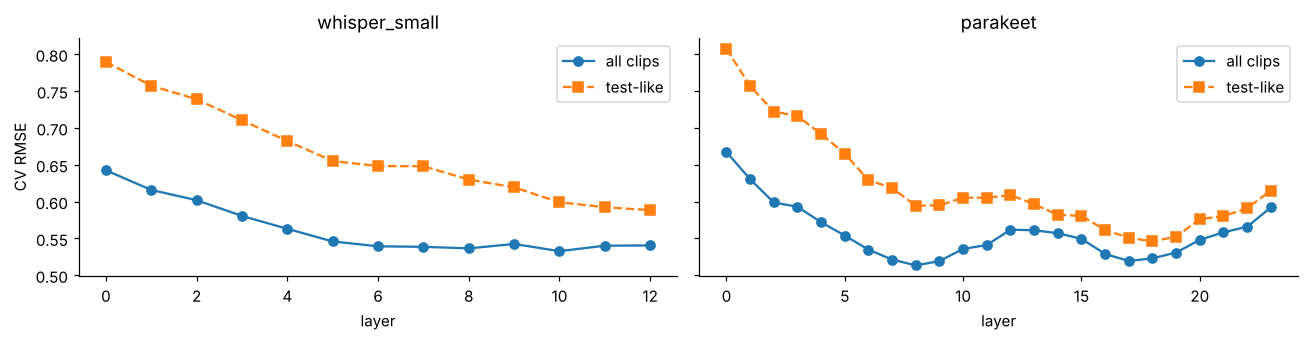

In [12]:
def pooled(name, split, files):
    z = [np.load(f'{CACHE}/{name}/{split}__{f[:-4]}.npz') for f in files]
    return np.stack([a['mean'] for a in z]), np.stack([a['std'] for a in z])

def layers(M, S, ls, use_std=False):
    parts = [M[:, ls].reshape(len(M), -1)] + ([S[:, ls].reshape(len(S), -1)] if use_std else [])
    return np.concatenate(parts, 1)

def svr(C=3.0, eps=0.05):
    return lambda: make_pipeline(StandardScaler(), SVR(C=C, epsilon=eps, gamma='scale'))

ENC = {n: (pooled(n, 'train', tr.filename), pooled(n, 'test', te.filename)) for n in ['whisper_small', 'parakeet']}
scan = []
for n, ((M, S), _) in ENC.items():
    for l in range(M.shape[1]):
        p, _, _ = oof(svr(), layers(M, S, [l]), folds=FOLDS[:5])
        scan.append(dict(encoder=n, layer=l, rmse=rmse(y, p), rmse_testlike=rmse(y[TL], p[TL])))
scan = pd.DataFrame(scan)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
for i, n in enumerate(ENC):
    s = scan[scan.encoder == n]
    ax[i].plot(s.layer, s.rmse, 'o-', label='all clips'); ax[i].plot(s.layer, s.rmse_testlike, 's--', label='test-like')
    ax[i].set_title(n); ax[i].set_xlabel('layer'); ax[i].legend()
ax[0].set_ylabel('CV RMSE'); plt.tight_layout(); plt.show()

* **Whisper:** the all-clip error flattens from block 6 on (best around 10), while the test-like error keeps falling towards the top.
* **Parakeet:** two good regions, around layer 8 and around layers 17–18. The upper region is clearly better on the test-like batch.

A small search over layer combinations (5-fold, same folds) settled on Whisper blocks 8–10 with mean + std, and Parakeet layers 6 + 18 with the mean only. Pairing one mid and one upper Parakeet layer beats any single layer by about 0.03; 8 + 18 is within noise of 6 + 18. Adding the std helped Whisper slightly but hurt Parakeet.

## 7. Level-1 models

Three components, chosen from a larger set of candidates. Weaker or redundant ones were dropped when they did not improve the stack on the test-like subset; the ablation below shows what each kept component adds.

| component | input | model |
|---|---|---|
| `whisper_svr` | Whisper-small.en layers 8–10, mean + std (4,608 dims) | RBF SVR, C=3, ε=0.05 |
| `parakeet_svr` | Parakeet layers 6 and 18, mean (2,048 dims) | RBF SVR, C=3, ε=0.05 |
| `text_lgb` | hand features + CoLA statistics (82 dims) | LightGBM, 500 trees, 15 leaves |

Notes on the SVRs: with standardised inputs and `gamma='scale'`, the fit is barely sensitive to C in the 3–30 range. Moving gamma by a factor of 2 either way, PCA-whitening, kernel ridge and sample weighting towards the test-like batch were all tried, and none of them helped.

In [13]:
Wtr, Wte = [layers(M, S, [8, 9, 10], use_std=True) for (M, S) in ENC['whisper_small']]
Ptr, Pte = [layers(M, S, [6, 18]) for (M, S) in ENC['parakeet']]
TEXT_COLS = HAND_COLS + COLA_COLS
Ttr = Htr.merge(Ctr[['filename'] + COLA_COLS], on='filename')[TEXT_COLS].values.astype(float)
Tte = Hte.merge(Cte[['filename'] + COLA_COLS], on='filename')[TEXT_COLS].values.astype(float)

def lgbm():
    return lgb.LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=15, min_child_samples=15, subsample=0.8,
                             subsample_freq=1, colsample_bytree=0.5, reg_lambda=1.0, random_state=0, verbose=-1, n_jobs=N_THREADS)

COMPONENTS = {'whisper_svr': (svr(), Wtr, Wte), 'parakeet_svr': (svr(), Ptr, Pte), 'text_lgb': (lgbm, Ttr, Tte)}
L1 = {}
for name, (mk, Xtr_, Xte_) in COMPONENTS.items():
    t0 = time.time(); L1[name] = oof(mk, Xtr_, Xte_)
    print({**report(L1[name][0], name), 'sec': round(time.time() - t0)})

{'model': 'whisper_svr', 'rmse': 0.5265, 'pearson': 0.8573, 'rmse_short': 0.5989, 'rmse_testlike': 0.5997, 'sec': 13}


{'model': 'parakeet_svr', 'rmse': 0.4812, 'pearson': 0.882, 'rmse_short': 0.5446, 'rmse_testlike': 0.5225, 'sec': 5}


{'model': 'text_lgb', 'rmse': 0.6663, 'pearson': 0.754, 'rmse_short': 0.6959, 'rmse_testlike': 0.6799, 'sec': 5}


## 8. Stack

A ridge regression over the three OOF predictions plus one indicator for the 45-second batch (40 s < duration < 46 s). The indicator lets the stack remove the level shift on that batch without retraining the level-1 models on duration. Interaction terms (prediction × indicator), non-negative weights, a LightGBM stacker and post-hoc isotonic or linear stretching were also tried, and all were equal or worse. Predictions are clipped to the rubric range [1, 5].

The stack is evaluated on the same 15 folds. Its CV score is close to an honest out-of-sample number for the full pipeline, with two caveats: the level-1 OOF predictions share folds with the stacker, and a handful of configurations were compared on these same folds. Both make it mildly optimistic.

In [14]:
NAMES = list(COMPONENTS)
is45 = lambda dur: ((dur > 40) & (dur < 46)).astype(float)[:, None]
Z = np.hstack([np.stack([L1[n][0] for n in NAMES], 1), is45(tr.dur.values)])       # OOF level-1 predictions
Zte = np.hstack([np.stack([L1[n][1] for n in NAMES], 1), is45(te.dur.values)])      # test predictions
Zin = np.hstack([np.stack([L1[n][2] for n in NAMES], 1), is45(tr.dur.values)])      # in-sample (full refit)

def stack_cv(Z, cols=None):
    cols = list(range(Z.shape[1])) if cols is None else cols
    p = np.zeros(len(y)); c = np.zeros(len(y))
    for a, b in FOLDS:
        p[b] += Ridge(alpha=1.0).fit(Z[a][:, cols], y[a]).predict(Z[b][:, cols]); c[b] += 1
    return np.clip(p / c, 1, 5)

stack_oof = stack_cv(Z)
stacker = Ridge(alpha=1.0).fit(Z, y)
print('weights:', dict(zip(NAMES + ['is45'], stacker.coef_.round(3))), '| intercept', round(stacker.intercept_, 3))
s45 = is45(tr.dur.values)[:, 0] == 1
print('level-1 OOF bias (pred - true) on 45 s clips:', {n: round(float((L1[n][0] - y)[s45].mean()), 3) for n in NAMES},
      '| on other clips:', {n: round(float((L1[n][0] - y)[~s45].mean()), 3) for n in NAMES})

rows = [report(L1[n][0], n) for n in NAMES]
rows.append(report(stack_cv(Z, list(range(len(NAMES)))), 'stack without is45'))
for i, n in enumerate(NAMES):
    rows.append(report(stack_cv(Z, [j for j in range(Z.shape[1]) if j != i]), f'stack without {n}'))
rows.append(report(stack_oof, 'STACK (final)'))
ablation = pd.DataFrame(rows).set_index('model'); ablation

weights: {'whisper_svr': np.float64(0.253), 'parakeet_svr': np.float64(0.763), 'text_lgb': np.float64(0.088), 'is45': np.float64(-0.129)} | intercept -0.341
level-1 OOF bias (pred - true) on 45 s clips: {'whisper_svr': 0.182, 'parakeet_svr': 0.126, 'text_lgb': 0.12} | on other clips: {'whisper_svr': -0.038, 'parakeet_svr': -0.028, 'text_lgb': -0.03}


,rmse,pearson,rmse_short,rmse_testlike
model,,,,
whisper_svr,0.5265,0.8573,0.5989,0.5997
parakeet_svr,0.4812,0.8820,0.5446,0.5225
text_lgb,0.6663,0.7540,0.6959,0.6799
stack without is45,0.4704,0.8861,0.5310,0.5154
stack without whisper_svr,0.4718,0.8853,0.5333,0.5083
stack without parakeet_svr,0.5039,0.8682,0.5578,0.5610
stack without text_lgb,0.4686,0.8870,0.5297,0.5126
STACK (final),0.4681,0.8873,0.5263,0.5099


Reading the ablation:
* Parakeet carries the stack. Without it, CV RMSE rises by about 0.035 and test-like RMSE by about 0.05.
* Whisper adds a little overall. On the test-like batch the difference is within noise in either direction.
* The 45-second indicator is worth about 0.005 on the test-like batch.
* The text model barely moves the stack. Its information (confidence, pausing, acceptability) is largely already in the encoder states. It is kept because it is cheap, interpretable, and the only component that sees the words explicitly.

### Training RMSE vs cross-validated RMSE

The training RMSE (required by the brief) is the final model's error on the clips it was fitted on: every component is refit on all 732 clips, and their in-sample predictions go through the fitted stacker. The SVRs nearly interpolate their training data, so this number is far below the CV figure and says little about generalisation. The cross-validated numbers are the ones to read.

In [15]:
train_pred = np.clip(stacker.predict(Zin), 1, 5)
summary = pd.DataFrame([
    {'': 'training (in-sample, full refit)', 'RMSE': rmse(y, train_pred), 'Pearson': pearsonr(y, train_pred)[0]},
    {'': '5x3 cross-validation, all clips', 'RMSE': rmse(y, stack_oof), 'Pearson': pearsonr(y, stack_oof)[0]},
    {'': '5x3 cross-validation, test-like batch (ids < 200)', 'RMSE': rmse(y[TL], stack_oof[TL]), 'Pearson': pearsonr(y[TL], stack_oof[TL])[0]},
    {'': 'constant (train mean)', 'RMSE': rmse(y, np.full(len(y), y.mean())), 'Pearson': np.nan},
]).set_index('').round(4)
summary

,RMSE,Pearson
,,
"training (in-sample, full refit)",0.0894,0.9977
"5x3 cross-validation, all clips",0.4681,0.8873
"5x3 cross-validation, test-like batch (ids < 200)",0.5099,0.7953
constant (train mean),1.0137,NaN


## 9. Robustness and error analysis

**Prompt shift.** Answers cluster by prompt (market, playground, best day, life goal, airport, ...), and the test set over-represents some prompts that are rare in training. A model that has learned "this topic tends to get high scores" would look fine under random folds and fail on test. As a check, transcripts are clustered into 12 topics (TF-IDF + k-means, fitted on train and test transcripts, no labels involved) and the whole pipeline is re-run with entire topics held out.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
texts = [load_asr('train', f)['text'] for f in tr.filename] + [load_asr('test', f)['text'] for f in te.filename]
topic = KMeans(12, random_state=0, n_init=10).fit_predict(TfidfVectorizer(stop_words='english', min_df=3, sublinear_tf=True).fit_transform(texts))
print('clips per topic, train:', np.bincount(topic[:len(tr)]).tolist())
print('clips per topic, test: ', np.bincount(topic[len(tr):], minlength=12).tolist())
GFOLDS = list(GroupKFold(6).split(np.zeros(len(y)), y, topic[:len(tr)]))
G = np.stack([oof(mk, X_, folds=GFOLDS)[0] for mk, X_, _ in COMPONENTS.values()], 1)
G = np.hstack([G, is45(tr.dur.values)])
g_stack = np.zeros(len(y))
for a, b in GFOLDS:
    g_stack[b] = Ridge(alpha=1.0).fit(G[a], y[a]).predict(G[b])
rob = pd.DataFrame([report(G[:, i], n) for i, n in enumerate(NAMES)] + [report(np.clip(g_stack, 1, 5), 'STACK')]).set_index('model')
rob.join(ablation[['rmse']].rename(columns={'rmse': 'rmse_random_folds'}))

clips per topic, train: [12, 87, 86, 9, 89, 50, 118, 94, 42, 67, 29, 49]
clips per topic, test:  [3, 9, 23, 27, 11, 66, 11, 15, 13, 4, 30, 4]


,rmse,pearson,rmse_short,rmse_testlike,rmse_random_folds
model,,,,,
whisper_svr,0.5482,0.8446,0.6448,0.6337,0.5265
parakeet_svr,0.4973,0.8743,0.5766,0.5553,0.4812
text_lgb,0.6935,0.7294,0.7459,0.7070,0.6663
STACK,0.4879,0.8768,0.5832,0.5582,NaN


Holding out whole topics costs the stack about 0.02 RMSE. The Parakeet component degrades least (+0.016), and Whisper and the text model a little more (+0.02–0.03). None of the blocks falls apart, so the pipeline is not leaning on topic.

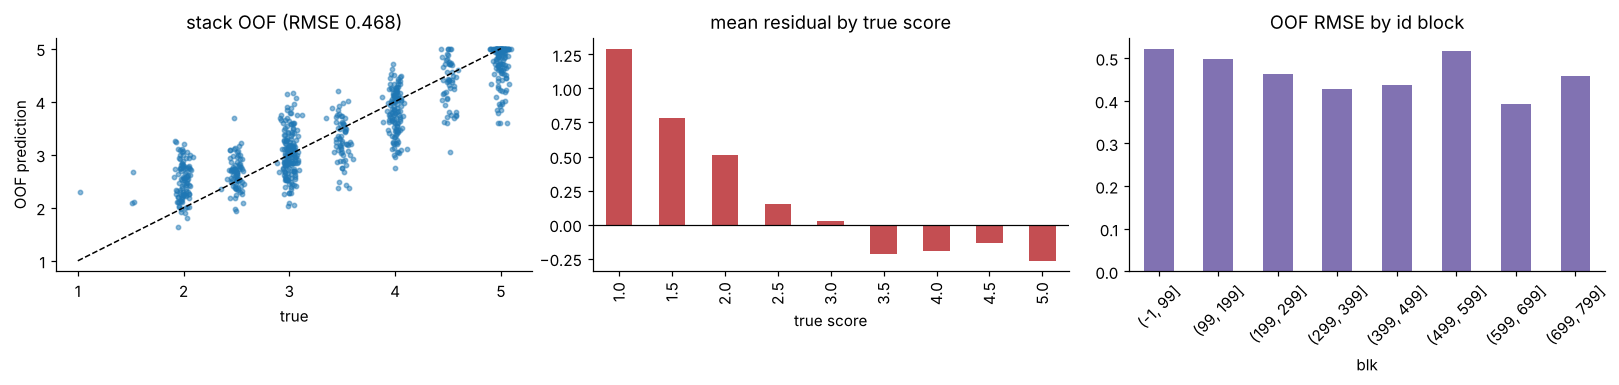

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
jit = np.random.default_rng(0).normal(0, 0.04, len(y))
ax[0].scatter(y + jit, stack_oof, s=8, alpha=0.5); ax[0].plot([1, 5], [1, 5], 'k--', lw=1)
ax[0].set_xlabel('true'); ax[0].set_ylabel('OOF prediction'); ax[0].set_title(f'stack OOF (RMSE {rmse(y, stack_oof):.3f})')
res = pd.DataFrame({'y': y, 'res': stack_oof - y})
res.groupby('y').res.mean().plot.bar(ax=ax[1], color='#C44E52'); ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_title('mean residual by true score'); ax[1].set_xlabel('true score')
blk = pd.cut(tr.id, [-1, 99, 199, 299, 399, 499, 599, 699, 799])
pd.DataFrame({'blk': blk, 'se': (stack_oof - y) ** 2}).groupby('blk').se.mean().pow(0.5).plot.bar(ax=ax[2], color='#8172B2')
ax[2].set_title('OOF RMSE by id block'); ax[2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

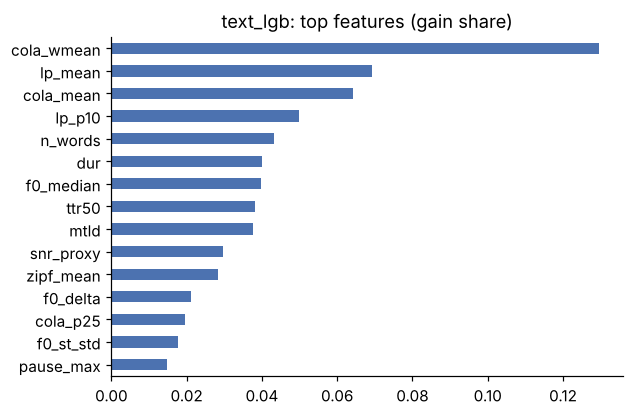

In [18]:
imp_model = lgbm().fit(Ttr, y)
imp = pd.Series(imp_model.booster_.feature_importance('gain'), TEXT_COLS).sort_values(ascending=False)
(imp / imp.sum()).head(15)[::-1].plot.barh(figsize=(6, 4), color='#4C72B0', title='text_lgb: top features (gain share)'); plt.show()

What the errors look like:
* The usual regression to the mean. Clips scored 2 are over-predicted and clips scored 5 are under-predicted. A post-hoc stretch did not fix this out of fold: the extremes are partly rater noise, and stretching amplifies it.
* Error is highest on the first id block (ids 0–99, the 45-second block that most resembles the test set). That makes the test-like RMSE the more realistic estimate of test error, not the all-clip RMSE.
* In the text model, the CoLA acceptability scores and ASR confidence dominate, followed by length and lexical diversity (word count, TTR, MTLD). Pause features correlate strongly with the score on their own but are largely redundant once confidence is in. Pitch level (`f0_median`) shows up too, which is more likely a speaker-population proxy than a grammar signal. The rule-based error counts rarely fire on spoken text and contribute little.

## 10. Submission

In [19]:
test_pred = np.clip(stacker.predict(Zte), 1, 5)
sub = pd.DataFrame({'filename': te.filename, 'label': np.round(test_pred, 4)})
assert len(sub) == 216 and sub.filename.is_unique and sub.label.between(1, 5).all()
sub.to_csv(f'{WORK}/submission.csv', index=False)
print(sub.label.describe().round(3).to_dict())
print('mean prediction, 45 s clips: %.3f | other clips: %.3f' % (test_pred[is45(te.dur.values)[:, 0] == 1].mean(), test_pred[is45(te.dur.values)[:, 0] == 0].mean()))
sub.head()

{'count': 216.0, 'mean': 3.238, 'std': 0.822, 'min': 1.986, '25%': 2.586, '50%': 3.129, '75%': 3.725, 'max': 5.0}
mean prediction, 45 s clips: 2.986 | other clips: 3.668


,filename,label
0,audio_128.wav,2.8244
1,audio_156.wav,3.7955
2,audio_19.wav,4.1586
3,audio_108.wav,2.1346
4,audio_206.wav,1.9985


In [20]:
results = {
    'cv_rmse': rmse(y, stack_oof), 'cv_pearson': float(pearsonr(y, stack_oof)[0]),
    'cv_rmse_testlike': rmse(y[TL], stack_oof[TL]), 'topic_heldout_rmse': rmse(y, np.clip(g_stack, 1, 5)),
    'train_rmse': rmse(y, train_pred), 'train_pearson': float(pearsonr(y, train_pred)[0]),
    'stack_weights': dict(zip(NAMES + ['is45'], map(float, stacker.coef_))), 'stack_intercept': float(stacker.intercept_),
    'n_train': int(len(y)), 'n_test': int(len(sub)),
}
json.dump(results, open(f'{WORK}/results.json', 'w'), indent=2)
pd.DataFrame({'filename': tr.filename, 'label': y, 'oof': stack_oof}).to_csv(f'{WORK}/oof_predictions.csv', index=False)
{k: (round(v, 4) if isinstance(v, float) else v) for k, v in results.items()}

{'cv_rmse': 0.4681,
 'cv_pearson': 0.8873,
 'cv_rmse_testlike': 0.5099,
 'topic_heldout_rmse': 0.4879,
 'train_rmse': 0.0894,
 'train_pearson': 0.9977,
 'stack_weights': {'whisper_svr': 0.2529675697684171,
  'parakeet_svr': 0.7632738067264604,
  'text_lgb': 0.08800762909439522,
  'is45': -0.1288917091320159},
 'stack_intercept': -0.3406,
 'n_train': 732,
 'n_test': 216}

## 11. Summary

The final model is a ridge stack over three components: SVRs on pooled Parakeet and Whisper encoder states, and LightGBM on transcript, timing, prosody and CoLA features. It uses one indicator for the 45-second recording batch. Results on the 732 rubric-scored training clips are in the tables above (section 8 for CV and training RMSE, section 9 for the topic-held-out check).

What mattered, roughly in order:
1. **The choice of speech encoder and layer.** Parakeet's FastConformer, pooled at a mid and an upper layer, was the strongest single block and the most robust to unseen prompts. Whisper-small adds a complementary view.
2. **Knowing the data.** Dropping the off-rubric 0.0 batch, and correcting for the 45-second batch that dominates the test set, both mattered more than any hyper-parameter.
3. **Text features are informative but redundant.** On their own they reach about 0.67 RMSE, but in the stack they add almost nothing on top of the encoders. CoLA acceptability is the most useful text signal.

Limitations and next steps:
* Everything is frozen-encoder and CPU-only. Fine-tuning an encoder on the scores, or attention pooling over frames, are the obvious next steps with a GPU.
* Transcripts come from a single ASR system. Grammar errors that Parakeet mishears or normalises are invisible to the text features. A second ASR pass, using disagreement between systems as a feature, is worth trying.
* 732 clips from a handful of recording batches is little data. The ~0.04 gap between all-clip and test-like CV RMSE shows the batch effect is real, and the leaderboard should be read with that in mind.